# Vibroacoustics — aluminium CCCC plate on a closed cavity

A flexible plate closes an air-filled box. The plate radiates into the cavity, the
cavity pushes back: neither problem is right on its own. This notebook runs the
**coupled** problem end to end, twice over:

1. a **modal analysis** — the natural frequencies and mode shapes of the coupled
   fluid–structure system;
2. a **direct frequency response** — the forced response solved frequency by
   frequency on the full coupled matrix,

and then checks one against the other: every peak of the direct sweep must sit on
a coupled natural frequency, and the two uncoupled references (plate *in vacuo*,
cavity with rigid walls) must bracket what the coupling does.

## The coupled problem

Structure (displacement $\mathbf w$) and fluid (pressure $\mathbf p$) are written in
the Eulerian $(\mathbf w, \mathbf p)$ formulation, with $e^{+j\omega t}$ and the
interface normal $\mathbf n$ **pointing out of the fluid**:

$$
\begin{bmatrix}
\mathbf K_s + j\omega\mathbf C_s - \omega^2 \mathbf M_s & -\mathbf K_c \\
-\rho_0\omega^2 \mathbf K_c^{T} & \mathbf K_a + j\omega\mathbf C_a - \omega^2 \mathbf M_a
\end{bmatrix}
\begin{Bmatrix}\mathbf w\\ \mathbf p\end{Bmatrix}
=
\begin{Bmatrix}\mathbf F_s\\ \mathbf F_a\end{Bmatrix},
\qquad
\mathbf K_c = \int_S \mathbf N_s^{T}\,\mathbf n\,\mathbf N_a\, dS .
$$

One single surface integral, $\mathbf K_c$, carries the whole interaction, and it
appears twice:

| Block | Physics | Where it lands |
|---|---|---|
| $-\mathbf K_c$ | the pressure loads the wall, $\mathbf F_s = \mathbf K_c\,\mathbf p$ | stiffness block |
| $-\rho_0\omega^2\mathbf K_c^{T}$ | the wall accelerates the fluid, $v_n = j\omega\,(\mathbf n\cdot\mathbf w)$ | mass block |

The matrix is therefore **unsymmetric** — not a loss of reciprocity, just the price
of pairing a displacement unknown with a pressure unknown. The same asymmetry
turns the eigenproblem $\mathbf K\mathbf x = \omega^2\mathbf M\mathbf x$ into an
unsymmetric one, which is why `solve_vibroacoustic_modal` does its shift-invert by
hand instead of handing `M` to ARPACK (ARPACK assumes a symmetric positive definite
mass matrix and silently returns wrong eigenvalues otherwise).

## Model

| | |
|---|---|
| Cavity | $0.40 \times 0.30 \times 0.50$ m, air, five rigid walls |
| Plate | aluminium, 1 mm, **clamped on all four edges (CCCC)**, on $z = L_z$ |
| Fluid mesh | CHEXA8, $24\times18\times12$ |
| Plate mesh | CQUAD4F, $24\times18$ — the top faces of the hexahedra (conforming) |
| Excitation | 1 N point force, normal, at the centre of the plate |
| Damping | structural loss factor $\eta_s$; walls lightly lined ($\zeta = 200$) so the cavity resonances stay finite |
| Input | one `ModelSpec`: the geometry and its parameters, the two materials, and the highest frequency of interest |

In [1]:
import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))                 # run from examples/

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh, spsolve

import pycafe
from pycafe.boundary_condition import AcousticBC
from pycafe.boundary_condition.acoustic_bc import build_impedance_operator
from pycafe.core.model_spec import AIR, Library, ModelSpec, aluminium, build_model
from pycafe.post_processing.post_processing_3d import plot_pressure_3d
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced
from pycafe.solver.solver_vibroacoustic import (
    build_coupled_blocks,
    expand_pressure,
    solve_vibroacoustic_frequency_sweep,
    solve_vibroacoustic_modal,
    structural_displacement_field,
)
from pycafe.solver.solver_vibroacoustic_modal import (
    build_cms_basis,
    build_coupled_modal_basis,
    project_coupled_system,
    solve_coupled_modal_frequency_sweep,
)

# ----------------------------- model data -----------------------------
LX, LY, LZ = 0.40, 0.30, 0.50          # cavity [m]; the plate lies on z = LZ
# The plate elements *are* the top faces of the hexahedra, so a finer plate
# is a finer fluid in x and y: refining only the shell would break the
# conformity the coupling integral relies on. The depth (z) carries only the
# acoustic wave, so it stays at what the wavelength asks for.
NX, NY, NZ = 24, 18, 12                # elements per direction

F_MIN, F_MAX, DF = 20.0, 450.0, 0.5     # sweep [Hz]
ETA_S = 0.02                            # structural loss factor
ZETA_WALL = 200.0                       # normalized wall impedance (alpha ~ 2%)

# One object holds the whole input: which geometry, which materials, and the
# frequency the mesh has to resolve. The element counts are given here only
# because this notebook is a validation case and its numbers are quoted
# against a known mesh; leaving them out lets f_max size the mesh instead.
spec = ModelSpec(
    geometry=Library("box_with_plate", Lx=LX, Ly=LY, Lz=LZ,
                     nx=NX, ny=NY, nz=NZ),
    fluid=AIR,
    structure=aluminium(t=1.0e-3, support="clamped"),   # CCCC
    f_max=F_MAX,
    output_path="plate_cavity.msh",
)
print(spec.describe())

RHO0, C0 = spec.fluid.rho0, spec.fluid.c0
T, RHO_S, E, NU = (spec.structure.t, spec.structure.rho_s,
                   spec.structure.E, spec.structure.nu)
D = spec.structure.D

print()
print(f"plate      D = {D:.3f} N m, mass = {RHO_S * T:.3f} kg/m2")
print(f"cavity     first axial modes: {C0 / (2 * LZ):.1f} Hz (z), "
      f"{C0 / (2 * LX):.1f} Hz (x), {C0 / (2 * LY):.1f} Hz (y)")
print(f"sizing     the 10-elements-per-wavelength rule asks for "
      f"{spec.element_size * 1e3:.0f} mm at {F_MAX:.0f} Hz; this mesh is "
      f"{LZ / NZ * 1e3:.0f} mm deep and {LX / NX * 1e3:.0f} x "
      f"{LY / NY * 1e3:.0f} mm across")
print(f"plate mesh {NX} x {NY} CQUAD4 over {LX} x {LY} m -> "
      f"{LX / NX * 1e3:.0f} mm elements, "
      f"{spec.structure.bending_wavelength(F_MAX) / (LX / NX):.0f} per bending "
      f"wavelength at {F_MAX:.0f} Hz")

ModelSpec
  geometry     Library('box_with_plate', Lx=0.4, Ly=0.3, Lz=0.5, nx=24, ny=18, nz=12)
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure    aluminium: t = 1.00 mm, E = 70 GPa, nu = 0.33, rho = 2700.0 kg/m3, clamped
  f_max        450.0 Hz (lambda = 762 mm)
  mesh size    76.2 mm (10 elements per wavelength)
  mesh file    plate_cavity.msh
  bending      lambda_b = 147 mm at f_max  (shorter than the acoustic one: check the panel mesh)

plate      D = 6.546 N m, mass = 2.700 kg/m2
cavity     first axial modes: 343.0 Hz (z), 428.8 Hz (x), 571.7 Hz (y)
sizing     the 10-elements-per-wavelength rule asks for 76 mm at 450 Hz; this mesh is 42 mm deep and 17 x 17 mm across
plate mesh 24 x 18 CQUAD4 over 0.4 x 0.3 m -> 17 mm elements, 9 per bending wavelength at 450 Hz


## 1. Mesh and system, from the spec

`build_model` does the three steps the spec describes: it builds the geometry
(`box_with_plate` — a transfinite HEXA8 cavity, and a QUAD4 plate whose elements
*are* the top faces of the hexahedra), checks the mesh against the pyCAFE contract
at `f_max`, and assembles the two domains with the coupling matrix.

The mesh is **conforming** by construction: plate nodes and fluid interface nodes
are the same nodes, so the coupling integral is assembled face by face without any
interpolation.

Physical groups written: `fluid` (volume), `plate` (structural domain *and*
interface), `rigid_walls` (the other five faces), `plate_clamp` (the four plate
edges). It also **draws the geometry first**, coloured by role — the fluid box transparent, the plate opaque on top, the held nodes as dots. A panel on the wrong face or a clamp on the wrong edge shows up there and nowhere in the numbers.

The report says what the mesh resolves — read the elements-per-wavelength line before trusting anything above it.

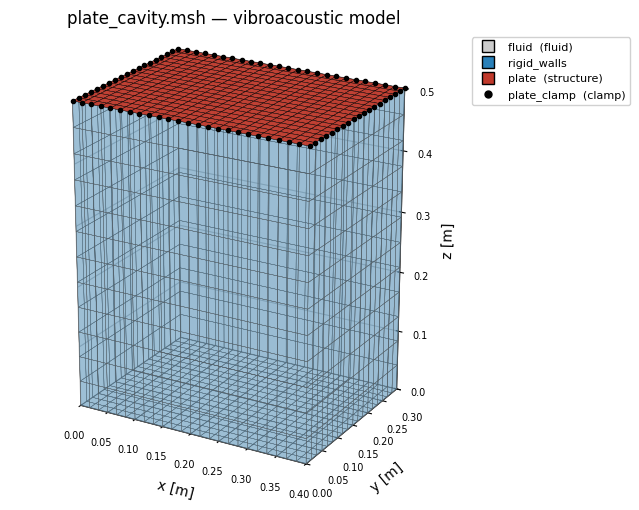

plate_cavity.msh  (vibroacoustic analysis)
------------------------------------------
  6175 nodes, 84 x Line 2, 1872 x Quadrilateral 4, 5184 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 432 faces, one fluid element behind each
  · fluid element size: 41.7 / 41.7 / 41.7 mm (min / mean / max)
  · good to ~1% up to 633 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 450 Hz: 18.3 elements per wavelength, dispersion error ~0.49%
  · selectable boundaries: rigid_walls
  => usable

analysis: vibroacoustic, mesh written to plate_cavity.msh


In [2]:
model = build_model(spec)

nodes = model["nodes"]
elements = model["elements"]
boundaries = model["boundaries"]
groups = model["groups"]
system = model["system"]                 # already assembled: it is a
                                         # vibroacoustic mesh, so build_model
                                         # called prepare_vibroacoustic_system
print(model["report"])
print(f"\nanalysis: {model['analysis']}, mesh written to {model['mesh_path']}")

## 2. What the coupling matrix has to satisfy

The system `build_model` returned holds the acoustic domain (1 pressure DOF per
node), the structural domain (6 DOF per node, CQUAD4F) with the clamp already
applied, and $\mathbf K_c$ over the interface faces.

Two checks are worth doing every time:

* the interface normals must point **out of the fluid** — here $+z$, since the
  plate closes the box from above;
* a uniform unit pressure must give back the **vector area** of the interface,
  $\mathbf K_c \mathbf 1 = \int_S \mathbf n\, dS$. It is the cheapest test that both
  the orientation and the surface Jacobian are right.

In [3]:
for role in ("fluid", "structure"):
    d = system["domains"][role]
    print(f"{role:<10} group '{d['group']}': {d['elem_type']} x {d['conn0'].shape[0]}")

iface = system["interface"]
coupling = system["coupling"]
print(f"interface  {iface['conn0'].shape[0]} faces, mean normal "
      f"{np.round(iface['normals'].mean(axis=0), 12)}")
print(f"Kc         {coupling['Kc'].shape}, {coupling['Kc'].nnz} nnz")
print(f"vector area int_S n dS = {np.round(coupling['area_vector'], 9)} m2  "
      f"(exact: [0, 0, {LX * LY:.4f}])")

n_s = system["structural"]["idx_free"].size
n_a = system["acoustic"]["nodes0"].size
print(f"support    {system['structural']['support']}, "
      f"{system['structural']['clamped_nodes0'].size} nodes held")
print(f"unknowns   {n_s} structural + {n_a} acoustic = {n_s + n_a}")

fluid      group 'fluid': CHEXA8 x 5184
structure  group 'plate': CQUAD4F x 432
interface  432 faces, mean normal [0. 0. 1.]
Kc         (37050, 6175), 12045 nnz
vector area int_S n dS = [0.   0.   0.12] m2  (exact: [0, 0, 0.1200])
support    clamped, 84 nodes held
unknowns   2346 structural + 6175 acoustic = 8521


## 3. The two uncoupled references

Before touching the coupled problem, solve the two halves separately. They are the
yardstick: the coupling can only be *read* as a shift away from them.

* **Plate in vacuo** — compared with Warburton's (1954) beam-function formula for a
  CCCC rectangular plate. It is an approximate Rayleigh solution, good to a few
  percent; the element itself is validated against Nastran DMIG and Leissa in
  `cquad4_plate_validation.ipynb`.
* **Rigid cavity** — compared with the exact modes of a rigid box,
  $f_{lmn} = \frac{c_0}{2}\sqrt{(l/L_x)^2 + (m/L_y)^2 + (n/L_z)^2}$.

In [4]:
# ---------------------------- plate in vacuo ----------------------------
K_s = system["structural"]["K_red"].tocsc()
M_s = system["structural"]["M_red"].tocsc()
vals, _ = eigsh(K_s, k=8, M=M_s, sigma=0.0, which="LM")
f_plate = np.sqrt(np.abs(np.sort(vals))) / (2 * np.pi)


def warburton_cccc(m, n, a, b, D, mass, nu):
    """Warburton (1954) frequency of a CCCC plate, mode (m, n)."""
    def GHJ(k):
        if k == 1:
            return 1.506, 1.248, 1.248
        G = k + 0.5
        H = J = G ** 2 * (1.0 - 2.0 / (G * np.pi))
        return G, H, J

    Gx, Hx, Jx = GHJ(m)
    Gy, Hy, Jy = GHJ(n)
    term = (Gx ** 4 / a ** 4 + Gy ** 4 / b ** 4
            + 2.0 / (a ** 2 * b ** 2) * (nu * Hx * Hy + (1.0 - nu) * Jx * Jy))
    return np.pi ** 2 * np.sqrt(D / mass) * np.sqrt(term) / (2.0 * np.pi)


ref = sorted((warburton_cccc(m, n, LX, LY, D, RHO_S * T, NU), (m, n))
             for m in range(1, 4) for n in range(1, 4))[:6]

print("plate in vacuo (CCCC)")
print("  mode   (m,n)    pyCAFE [Hz]   Warburton [Hz]   diff")
for i, (f_ref, mn) in enumerate(ref):
    print(f"  {i + 1:^4d}   {str(mn):<7} {f_plate[i]:11.2f}   {f_ref:12.2f}   "
          f"{(f_plate[i] / f_ref - 1) * 100:+6.2f} %")

# ---------------------------- rigid cavity ------------------------------
f_cav, _ = solve_modal_acoustic_reduced(
    system["acoustic"]["K"], system["acoustic"]["M"], num_modes=5
)
exact = sorted((C0 / 2 * np.sqrt((l / LX) ** 2 + (m / LY) ** 2 + (n / LZ) ** 2),
                (l, m, n))
               for l in range(3) for m in range(3) for n in range(3))[1:6]

print("\nrigid cavity")
print("  mode  (l,m,n)   pyCAFE [Hz]   exact [Hz]   error")
for i, (f_ex, lmn) in enumerate(exact):
    print(f"  {i + 1:^4d}  {str(lmn):<9} {f_cav[i]:10.2f}   {f_ex:9.2f}   "
          f"{(f_cav[i] / f_ex - 1) * 100:+6.3f} %")

plate in vacuo (CCCC)
  mode   (m,n)    pyCAFE [Hz]   Warburton [Hz]   diff
   1     (1, 1)        79.04          79.34    -0.38 %
   2     (2, 1)       132.81         133.26    -0.34 %
   3     (1, 2)       187.61         186.77    +0.45 %
   4     (3, 1)       222.81         221.94    +0.39 %
   5     (2, 2)       236.61         236.66    -0.02 %
   6     (3, 2)       321.14         320.48    +0.21 %



rigid cavity
  mode  (l,m,n)   pyCAFE [Hz]   exact [Hz]   error
   1    (0, 0, 1)     343.98      343.00   +0.286 %
   2    (1, 0, 0)     429.06      428.75   +0.071 %
   3    (1, 0, 1)     549.92      549.07   +0.155 %
   4    (0, 1, 0)     572.39      571.67   +0.127 %
   5    (0, 1, 1)     667.80      666.67   +0.169 %


## 4. Coupled modal analysis

`solve_vibroacoustic_modal` solves the undamped coupled eigenproblem

$$
\mathbf K = \begin{bmatrix}\mathbf K_s & -\mathbf K_c\\ \mathbf 0 & \mathbf K_a\end{bmatrix},
\qquad
\mathbf M = \begin{bmatrix}\mathbf M_s & \mathbf 0\\ \rho_0\mathbf K_c^{T} & \mathbf M_a\end{bmatrix} .
$$

A **zero-frequency mode** always shows up here: the cavity is completely sealed by
rigid walls and a flexible one, no pressure is pinned anywhere, so the uniform
pressure field costs no energy. It is the acoustic counterpart of a rigid-body
mode — pin one pressure DOF through `pressure_zero_nodes0` if you want it gone.

To tell a plate-like mode from a cavity-like one, split the modal energy between
the two fields:

$$
E_s = \omega^2\,\mathbf w^{T}\mathbf M_s\mathbf w
\qquad
E_a = \frac{1}{\rho_0}\,\mathbf p^{T}\mathbf M_a\mathbf p ,
$$

the structural kinetic energy against the acoustic potential energy
($\mathbf M_a = \int \mathbf N^{T}\mathbf N / c_0^2\, dV$, so $\mathbf p^T\mathbf M_a\mathbf p/\rho_0$
is exactly $\int p^2/(\rho_0 c_0^2)\,dV$). A mode with $E_s/(E_s+E_a)\approx 1$ is
the plate moving, $\approx 0$ is the air resonating, anything in between is a
genuinely coupled mode.

In [5]:
blocks_free = build_coupled_blocks(system)          # undamped, for the modes

t0 = time.time()
f_coupled, modes = solve_vibroacoustic_modal(system, num_modes=12,
                                             blocks=blocks_free)
t_modal = time.time() - t0
print(f"{f_coupled.size} coupled modes in {t_modal:.2f} s "
      f"({blocks_free['n_s'] + blocks_free['n_a']} unknowns)\n")

Ms_b, Ma_b = blocks_free["Ms"], blocks_free["Ma"]
ns = blocks_free["n_s"]

uncoupled = np.concatenate([f_plate, f_cav])
labels = ([f"plate {i + 1}" for i in range(f_plate.size)]
          + [f"cavity {lmn}" for _, lmn in exact])

print("   f [Hz]   Es/(Es+Ea)   character        nearest uncoupled     shift")
frac = np.zeros(f_coupled.size)
for i, f in enumerate(f_coupled):
    w, p = modes[:ns, i], modes[ns:, i]
    Es = (2 * np.pi * f) ** 2 * (w @ (Ms_b @ w))
    Ea = (p @ (Ma_b @ p)) / RHO0
    frac[i] = Es / (Es + Ea) if (Es + Ea) > 0 else 0.0

    if f < 1.0:
        print(f"{f:9.2f}   {frac[i]:9.3f}   uniform pressure of the sealed cavity")
        continue
    kind = ("plate-like " if frac[i] > 0.75 else
            "cavity-like" if frac[i] < 0.25 else "coupled    ")
    j = int(np.argmin(np.abs(uncoupled - f)))
    print(f"{f:9.2f}   {frac[i]:9.3f}   {kind}      {labels[j]:<16} "
          f"{(f / uncoupled[j] - 1) * 100:+7.2f} %")

12 coupled modes in 0.32 s (8521 unknowns)

   f [Hz]   Es/(Es+Ea)   character        nearest uncoupled     shift
     0.00       0.000   uniform pressure of the sealed cavity
    84.83       0.846   plate-like       plate 1            +7.32 %
   130.59       0.999   plate-like       plate 2            -1.67 %
   185.09       0.999   plate-like       plate 3            -1.34 %
   220.51       0.990   plate-like       plate 4            -1.03 %
   234.18       0.999   plate-like       plate 5            -1.03 %
   318.49       0.999   plate-like       plate 6            -0.82 %
   339.81       0.390   coupled          cavity (0, 0, 1)   -1.21 %
   344.52       0.989   plate-like       cavity (0, 0, 1)   +0.16 %
   363.37       0.617   coupled          plate 8            +1.86 %
   399.17       0.957   plate-like       cavity (1, 0, 0)   -6.97 %
   432.58       0.061   cavity-like      cavity (1, 0, 0)   +0.82 %


### What the coupling did

The first plate mode is the interesting one: the sealed air behaves as a spring in
parallel with the plate stiffness, so its frequency goes **up**. Higher plate modes
move the air back and forth inside the cavity without compressing much of it — the
air is then mostly added *mass*, and those frequencies drift **down** instead.

In [6]:
flex = f_coupled[f_coupled > 1.0]
print(f"1st plate mode : {f_plate[0]:6.2f} Hz in vacuo -> {flex[0]:6.2f} Hz coupled "
      f"({(flex[0] / f_plate[0] - 1) * 100:+.1f} %, trapped air = spring)")
for i in (1, 2, 3):
    print(f"plate mode {i + 1}   : {f_plate[i]:6.2f} Hz in vacuo -> "
          f"{flex[i]:6.2f} Hz coupled ({(flex[i] / f_plate[i] - 1) * 100:+.1f} %)")

1st plate mode :  79.04 Hz in vacuo ->  84.83 Hz coupled (+7.3 %, trapped air = spring)
plate mode 2   : 132.81 Hz in vacuo -> 130.59 Hz coupled (-1.7 %)
plate mode 3   : 187.61 Hz in vacuo -> 185.09 Hz coupled (-1.3 %)
plate mode 4   : 222.81 Hz in vacuo -> 220.51 Hz coupled (-1.0 %)


## 5. Coupled mode shapes

The first two coupled modes, one per row — **the shell on the left, the cavity on
the right** — because an eigenvector of the coupled problem is one object with two
halves, and reading them apart hides which motion drives which.

Each field is normalized on its own maximum: the raw eigenvector mixes metres and
pascals, so the ratio between the two halves has no meaning by itself. Which mode
is plate-like and which is cavity-like is in the table of section 4; the pictures
carry the frequency and nothing else.

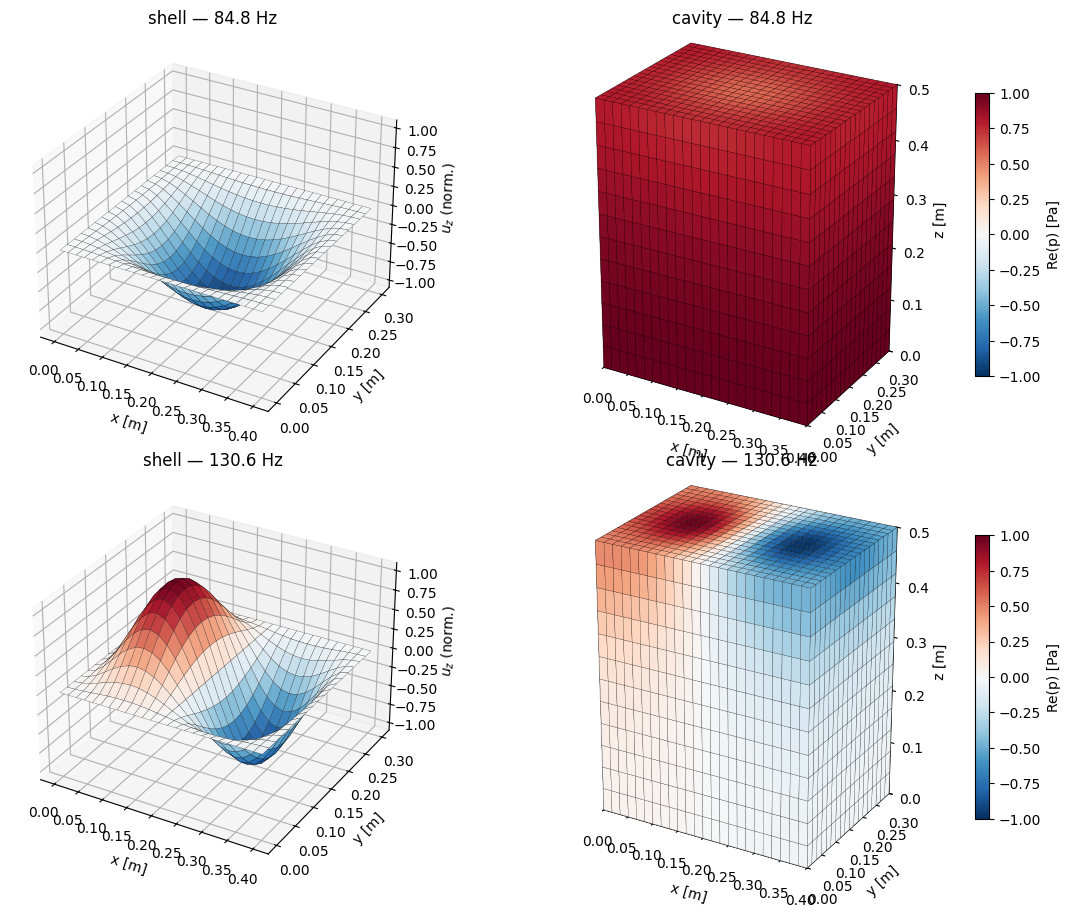

mode at   84.83 Hz: plate-like, Es/(Es+Ea) = 0.85
mode at  130.59 Hz: plate-like, Es/(Es+Ea) = 1.00
rigid-box (0,0,1) reference: 343.0 Hz


In [7]:
plate0 = system["structural"]["nodes0"]
# Gmsh coordinates carry round-off, so the grid lines are recovered from
# rounded values; the inverse indices then scatter any nodal field onto
# the structured plate grid.
xs, ix = np.unique(np.round(nodes[plate0, 0], 6), return_inverse=True)
ys, iy = np.unique(np.round(nodes[plate0, 1], 6), return_inverse=True)
X, Y = np.meshgrid(xs, ys)


def plate_shape(w_red, idx_s):
    """Transverse displacement of the plate, on the structured plate grid."""
    field = structural_displacement_field(w_red, idx_s, nodes.shape[0])
    uz = np.zeros((ys.size, xs.size))
    uz[iy, ix] = np.real(field[plate0, 2])
    return uz / np.abs(uz).max()


def draw_plate(ax, uz, title):
    """Left panel: the shell."""
    ax.plot_surface(X, Y, uz, cmap="RdBu_r", vmin=-1, vmax=1,
                    linewidth=0.15, edgecolor="k", alpha=0.95)
    ax.set(xlabel="x [m]", ylabel="y [m]", zlabel="$u_z$ (norm.)",
           zlim=(-1.1, 1.1))
    ax.set_title(title)


# The first two modes of the coupled problem, skipping the 0 Hz uniform
# pressure of the sealed cavity.
flexible = np.where(f_coupled > 1.0)[0][:2]

fig = plt.figure(figsize=(12, 10))
for row, idx in enumerate(flexible):
    ax_s = fig.add_subplot(2, 2, 2 * row + 1, projection="3d")
    draw_plate(ax_s, plate_shape(modes[:ns, idx], blocks_free["idx_s"]),
               f"shell — {f_coupled[idx]:.1f} Hz")

    ax_a = fig.add_subplot(2, 2, 2 * row + 2, projection="3d")
    p_mode = expand_pressure(modes[ns:, idx], blocks_free["idx_a"],
                             nodes.shape[0])
    plot_pressure_3d(
        nodes, elements, p_mode / np.abs(p_mode).max(),
        part="real", cmap="RdBu_r", clim=(-1, 1), ax=ax_a, show=False,
        title=f"cavity — {f_coupled[idx]:.1f} Hz",
    )

# tight_layout does not know about 3D axes: leave the rows apart by hand,
# or the title of the second lands on the labels of the first.
fig.subplots_adjust(hspace=0.28, wspace=0.05, top=0.94, bottom=0.06)
plt.show()

for idx in flexible:
    kind = ("plate-like" if frac[idx] > 0.75 else
            "cavity-like" if frac[idx] < 0.25 else "coupled")
    print(f"mode at {f_coupled[idx]:7.2f} Hz: {kind}, "
          f"Es/(Es+Ea) = {frac[idx]:.2f}")
print(f"rigid-box (0,0,1) reference: {C0 / (2 * LZ):.1f} Hz")

## 6. Direct frequency response

Now the forced problem: 1 N normal at the centre of the plate, nothing applied to
the fluid. At every frequency `solve_vibroacoustic_frequency_sweep` assembles
$\mathbf A(\omega)$ and factorizes it — the matrix is complex **and** unsymmetric,
so nothing can be reused from one frequency to the next and the cost grows linearly
with the number of lines in the sweep.

Damping, without which the peaks would be infinite and the sweep would only measure
its own frequency resolution:

* **structure** — loss factor, $\mathbf K_s(1 + j\eta_s)$, via `eta_s`;
* **fluid** — the five walls get a large but finite normalized impedance
  $\zeta = 200$ (absorption $\alpha = 4\zeta/(1+\zeta)^2 \approx 2\%$), assembled by
  the standard acoustic BC layer and passed in as `C_a`.

In [8]:
# Acoustic damping: lightly lined walls -> C_a (frequency independent here)
bc_walls = AcousticBC().add_impedance("rigid_walls", ZETA_WALL)
C_a = build_impedance_operator(
    bc_walls, nodes=nodes, rho=RHO0, c0=C0,
    boundaries=boundaries, groups=groups, elements=elements, boundary_dim=2,
).at(0.0)
alpha = 4 * ZETA_WALL / (1 + ZETA_WALL) ** 2
print(f"C_a: {C_a.nnz} nnz, wall absorption coefficient alpha = {alpha:.3f}")

blocks = build_coupled_blocks(system, C_a=C_a, eta_s=ETA_S)

# Driving DOF: transverse translation of the node closest to the plate centre
idx_s = system["structural"]["idx_free"]
node_of_dof, component = idx_s // 6, idx_s % 6
centre = np.array([LX / 2, LY / 2, LZ])
plate_nodes = np.unique(node_of_dof)
drive_node = plate_nodes[np.argmin(
    np.linalg.norm(nodes[plate_nodes] - centre, axis=1)
)]
dof = int(np.where((node_of_dof == drive_node) & (component == 2))[0][0])

F_s = np.zeros(blocks["n_s"])
F_s[dof] = 1.0                      # 1 N along +z
print(f"drive at node {drive_node} {np.round(nodes[drive_node], 4)}, "
      f"reduced DOF {dof}")

frequencies = np.arange(F_MIN, F_MAX + DF, DF)
t0 = time.time()
result = solve_vibroacoustic_frequency_sweep(
    system, frequencies, F_s=F_s, blocks=blocks, verbose=False,
)
t_direct = time.time() - t0
print(f"direct sweep: {frequencies.size} frequencies, "
      f"{blocks['n_s'] + blocks['n_a']} unknowns, {t_direct:.1f} s "
      f"({1e3 * t_direct / frequencies.size:.0f} ms per frequency)")
print(f"for comparison, the 14 coupled modes took {t_modal:.2f} s")

C_a: 13087 nnz, wall absorption coefficient alpha = 0.020
drive at node 798 [0.2  0.15 0.5 ], reduced DOF 1172


direct sweep: 861 frequencies, 8521 unknowns, 567.6 s (659 ms per frequency)
for comparison, the 14 coupled modes took 0.32 s


### The same force on the plate alone

Solving $(\mathbf K_s(1+j\eta_s) - \omega^2\mathbf M_s)\mathbf w = \mathbf F_s$ with the
very same mesh and damping isolates what the air is responsible for.

In [9]:
K_sc = K_s.astype(complex) * (1.0 + 1j * ETA_S)
w_vacuo = np.array([
    spsolve((K_sc - (2 * np.pi * f) ** 2 * M_s).tocsc(), F_s.astype(complex))[dof]
    for f in frequencies
])

w_centre = result["w"][dof]

# Microphone in a corner of the cavity, away from any nodal plane
idx_a = result["idx_a"]
mic_node = idx_a[np.argmin(
    np.linalg.norm(nodes[idx_a] - np.array([0.02, 0.02, 0.02]), axis=1)
)]
mic_row = int(np.where(idx_a == mic_node)[0][0])
p_mic = result["p"][mic_row]
print(f"microphone at node {mic_node} {np.round(nodes[mic_node], 4)}")
print(f"peak |w| = {np.abs(w_centre).max():.3e} m, "
      f"peak |p| = {np.abs(p_mic).max():.1f} Pa")

microphone at node 212 [0.0167 0.0167 0.    ]
peak |w| = 2.594e-03 m, peak |p| = 228.1 Pa


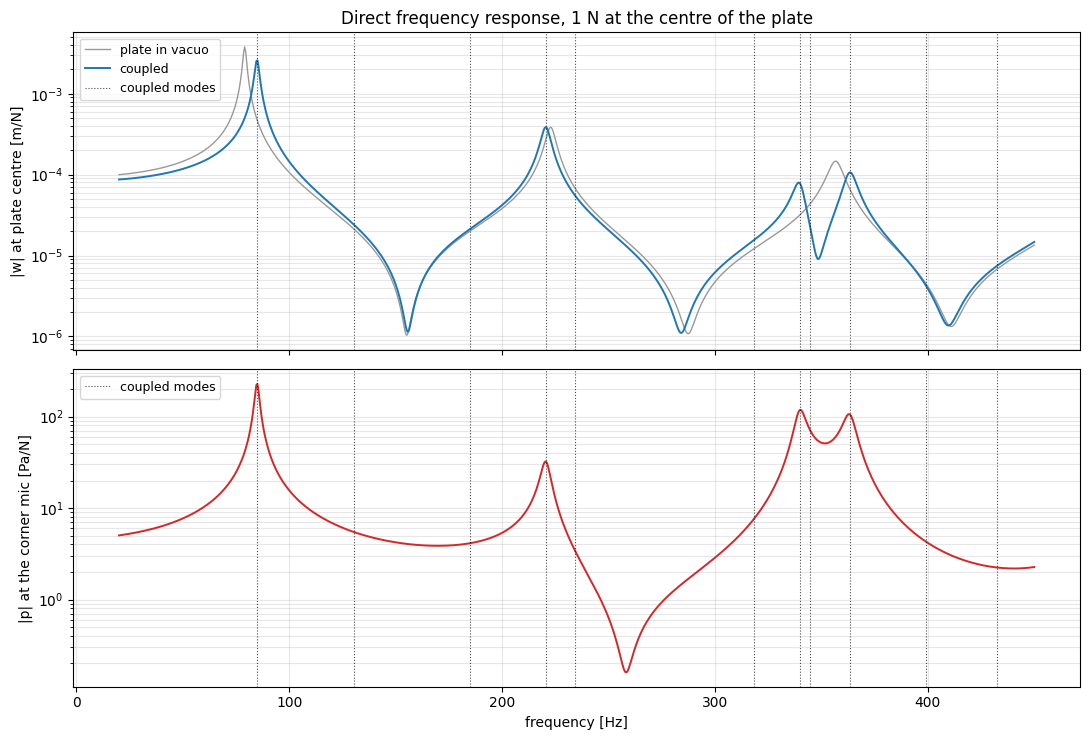

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

axes[0].semilogy(frequencies, np.abs(w_vacuo), lw=1.0, color="0.6",
                 label="plate in vacuo")
axes[0].semilogy(frequencies, np.abs(w_centre), lw=1.4, color="C0",
                 label="coupled")
axes[0].set_ylabel("|w| at plate centre [m/N]")
axes[0].set_title("Direct frequency response, 1 N at the centre of the plate")

axes[1].semilogy(frequencies, np.abs(p_mic), lw=1.4, color="C3")
axes[1].set(xlabel="frequency [Hz]", ylabel="|p| at the corner mic [Pa/N]")

for ax in axes:
    for k, f in enumerate(f_coupled[(f_coupled > F_MIN) & (f_coupled < F_MAX)]):
        ax.axvline(f, color="k", ls=":", lw=0.8, alpha=0.7,
                   label="coupled modes" if k == 0 else None)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Modal vs direct — the cross-check

Every peak of the direct sweep must land on a coupled natural frequency. The peak
positions are refined by fitting a parabola through the three points around each
local maximum, so the comparison is not limited by the 0.5 Hz step of the sweep.

Modes that are *missing* from the response are not an error: a point force at the
centre of the plate cannot excite a mode with a node line there, which is exactly
what happens to the modes antisymmetric in $x$ or $y$.

In [11]:
def find_peaks(freqs, response):
    """Local maxima of |response|, refined by a parabola on log amplitude."""
    a = np.log(np.abs(response) + 1e-300)
    out = []
    for i in range(1, freqs.size - 1):
        if a[i] > a[i - 1] and a[i] >= a[i + 1]:
            denom = a[i - 1] - 2 * a[i] + a[i + 1]
            shift = 0.5 * (a[i - 1] - a[i + 1]) / denom if denom != 0 else 0.0
            out.append(freqs[i] + shift * (freqs[1] - freqs[0]))
    return np.array(out)


peaks_w = find_peaks(frequencies, w_centre)
peaks_p = find_peaks(frequencies, p_mic)

# Merge the two peak lists: the same resonance shows up in both signals.
rows = [[f, {"w"}] for f in peaks_w]
for f in peaks_p:
    near = [r for r in rows if abs(r[0] - f) < 1.0]
    if near:
        near[0][1].add("p")
    else:
        rows.append([f, {"p"}])
rows.sort()

print("  peak of the sweep     seen in    nearest coupled mode      difference")
for f_pk, seen in rows:
    j = int(np.argmin(np.abs(f_coupled - f_pk)))
    kind = ("plate-like " if frac[j] > 0.75 else
            "cavity-like" if frac[j] < 0.25 else "coupled    ")
    print(f"  {f_pk:8.2f} Hz          {'+'.join(sorted(seen)):<4}    "
          f"{f_coupled[j]:8.2f} Hz  ({kind})   {f_pk - f_coupled[j]:+6.2f} Hz")

all_peaks = np.array([r[0] for r in rows])
missed = [f for f in f_coupled[(f_coupled > F_MIN) & (f_coupled < F_MAX)]
          if np.min(np.abs(all_peaks - f)) > 1.0]
print("\nmodes not excited by a force at the centre (node line there): "
      f"{np.round(missed, 2)} Hz")

  peak of the sweep     seen in    nearest coupled mode      difference
     84.82 Hz          p+w        84.83 Hz  (plate-like )    -0.01 Hz
    220.49 Hz          p+w       220.51 Hz  (plate-like )    -0.01 Hz
    339.35 Hz          p+w       339.81 Hz  (coupled    )    -0.46 Hz
    363.48 Hz          p+w       363.37 Hz  (coupled    )    +0.11 Hz

modes not excited by a force at the centre (node line there): [130.59 185.09 234.18 318.49 344.52 399.17 432.58] Hz


## 8. Pressure field at resonance

The two peaks look nothing alike inside the cavity. On the plate-like resonance the
plate drives the air as a piston and the pressure is nearly uniform over the depth;
on the cavity-like one the field is the standing wave of the box, with its node
plane halfway up. Magnitudes are plotted rather than real parts: at a resonance the
response is in quadrature with the force, so `part="real"` would show mostly the
off-resonance remainder.

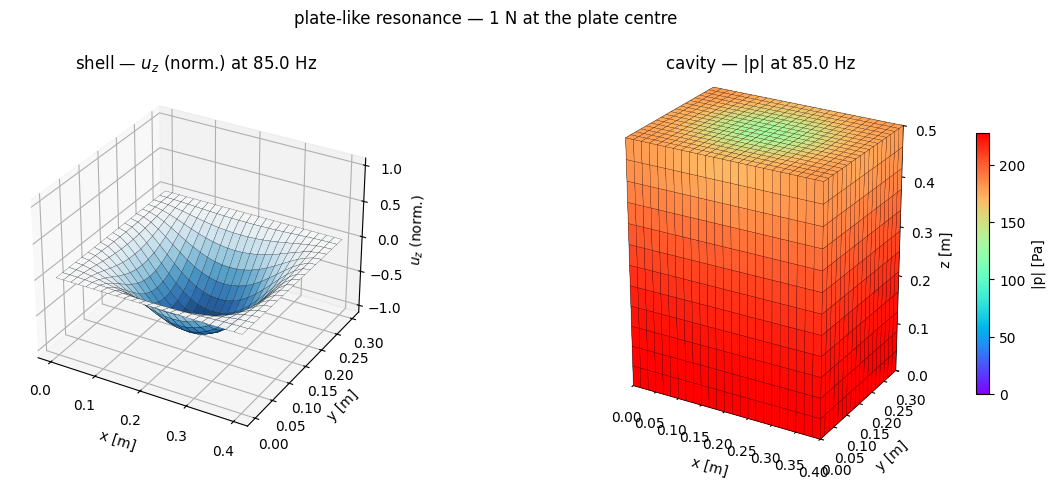

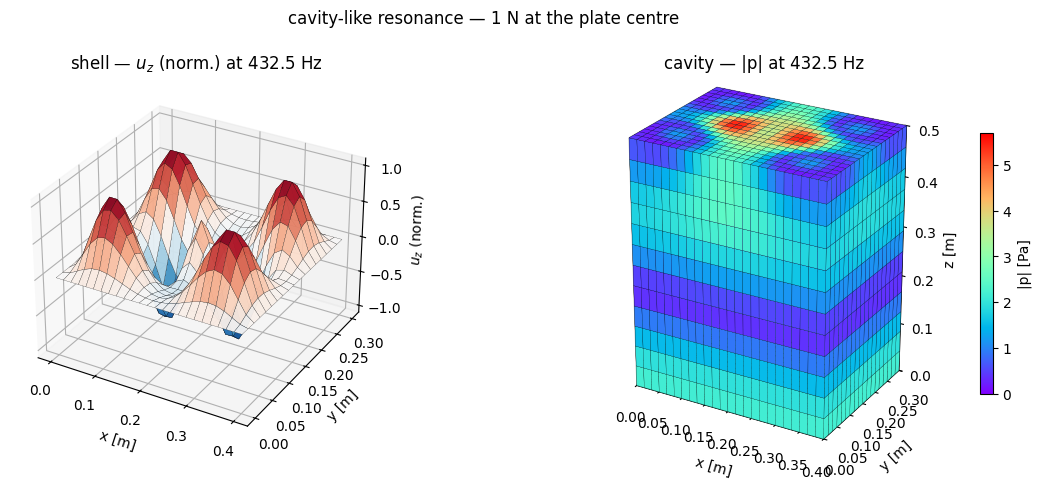

In [12]:
p_full = expand_pressure(result["p"], result["idx_a"], nodes.shape[0])

i_plate = int(np.argmax(frac > 0.75))                       # first plate-like
i_cav = int(np.argmin(np.where(f_coupled > 1.0, frac, 9)))  # first cavity-like

for f_target, name in [(f_coupled[i_plate], "plate-like"),
                       (f_coupled[i_cav], "cavity-like")]:
    k = int(np.argmin(np.abs(frequencies - f_target)))

    fig = plt.figure(figsize=(12, 4.6))
    ax_s = fig.add_subplot(1, 2, 1, projection="3d")
    draw_plate(ax_s, plate_shape(result["w"][:, k], result["idx_s"]),
               f"shell — $u_z$ (norm.) at {frequencies[k]:.1f} Hz")

    ax_a = fig.add_subplot(1, 2, 2, projection="3d")
    plot_pressure_3d(
        nodes, elements, p_full[:, k], part="abs", ax=ax_a, show=False,
        title=f"cavity — |p| at {frequencies[k]:.1f} Hz",
    )

    fig.suptitle(f"{name} resonance — 1 N at the plate centre", y=0.99)
    plt.tight_layout()
    plt.show()

## 9. Two optional reduced models

Everything above used the **direct** solver: exact, one factorization per
frequency, 861 factorizations for the sweep. When that becomes the bottleneck,
the response can be expanded on a small basis instead,

$$\mathbf q = \begin{Bmatrix}\mathbf w\\ \mathbf p\end{Bmatrix}
\simeq \mathbf \Phi\, \boldsymbol\varphi , \qquad m \ll n_s + n_a ,$$

and an $m \times m$ system solved at each frequency. Two bases are available.
Neither is required to run a coupled analysis — they are accelerations, and the
direct solver stays the reference to check them against.

| | Cost to build | Efficiency per vector |
|---|---|---|
| **9a** Modal expansion on the coupled modes | high — one unsymmetric eigenproblem | high |
| **9b** Component Mode Synthesis | low — two symmetric eigenproblems | lower, needs more vectors |

Both feed the same solver, `solve_coupled_modal_frequency_sweep`.

### 9a. Modal expansion on the coupled modes

The basis is the set of coupled modes already computed in section 4 — each one a
structural shape *together with* its pressure field:

$$\mathbf q \simeq \sum_{c=1}^{m_c}\varphi_c
\begin{Bmatrix}\mathbf \Phi_{s,c}\\ \mathbf \Phi_{a,c}\end{Bmatrix}.$$

Because the coupled matrices are unsymmetric, the eigenproblem has **two**
families of eigenvectors, right and left,

$$\mathbf K \mathbf \Phi^R_c = \omega_c^2 \mathbf M \mathbf \Phi^R_c ,
\qquad
\mathbf K^T \mathbf \Phi^L_c = \omega_c^2 \mathbf M^T \mathbf \Phi^L_c ,$$

and the projection must use both, $(\mathbf \Phi^L)^T \mathbf A \mathbf \Phi^R$.
The left ones cost nothing extra here: for this block structure they follow from
the right ones without a second eigensolve,

$$\mathbf \Phi^L_c = \begin{Bmatrix}\rho_0\,\omega_c^2\,\mathbf \Phi_{s,c}\\
\mathbf \Phi_{a,c}\end{Bmatrix}$$

— same acoustic part, structural part scaled by $\rho_0\omega_c^2$.

Right modes are *not* orthogonal to one another. What holds is **biorthogonality**
between the two families, $(\mathbf \Phi^L_i)^T \mathbf M \mathbf \Phi^R_j = 0$ for
$i \neq j$, so normalizing the diagonal to 1 gives

$$\tilde{\mathbf M} = \mathbf I , \qquad
\tilde{\mathbf K} = \mathrm{diag}(\omega_c^2) .$$

Damping is not diagonalized by the same argument — the lined walls couple the
modes — so the $m_c \times m_c$ system is solved dense at every frequency.

In [13]:
blocks_undamped = build_coupled_blocks(system, C_a=C_a)   # eta_s belongs to the sweep

t0 = time.time()
coupled_basis = build_coupled_modal_basis(blocks=blocks_undamped, num_modes=40)
t_basis_coupled = time.time() - t0

m_c = coupled_basis["Phi_R"].shape[1]
print(f"{m_c} coupled modes up to {coupled_basis['freqs'].max():.0f} Hz, "
      f"built in {t_basis_coupled:.2f} s "
      f"(full model: {blocks_undamped['n_s'] + blocks_undamped['n_a']} unknowns)")

# The projected matrices are computed, not assumed: this is the check.
Kt, Ct, Mt = project_coupled_system(coupled_basis, eta_s=ETA_S)
omega2 = coupled_basis["omegas"] ** 2

print(f"biorthogonality residual        : "
      f"{coupled_basis['biorthogonality']:.1e}")
print(f"max |Mt - I|                    : "
      f"{np.abs(Mt - np.eye(m_c)).max():.1e}")
print(f"max |Re(Kt) - diag(omega_c^2)| / max(omega_c^2) : "
      f"{np.abs(np.real(Kt) - np.diag(omega2)).max() / omega2.max():.1e}")

off = np.abs(Ct - np.diag(np.diag(Ct)))
print(f"damping: largest off-diagonal / largest diagonal : "
      f"{off.max() / np.abs(np.diag(Ct)).max():.2f}  "
      "(the lined walls couple the modes, so Ct is dense)")

40 coupled modes up to 998 Hz, built in 0.53 s (full model: 8521 unknowns)
biorthogonality residual        : 1.0e-02
max |Mt - I|                    : 1.0e-02
max |Re(Kt) - diag(omega_c^2)| / max(omega_c^2) : 6.3e-03
damping: largest off-diagonal / largest diagonal : 0.46  (the lined walls couple the modes, so Ct is dense)


In [14]:
t0 = time.time()
res_modal = solve_coupled_modal_frequency_sweep(
    coupled_basis, frequencies, F_s=F_s, eta_s=ETA_S, return_modal=True,
)
t_modal_sweep = time.time() - t0

err_w = np.linalg.norm(res_modal["w"] - result["w"]) / np.linalg.norm(result["w"])
err_p = np.linalg.norm(res_modal["p"] - result["p"]) / np.linalg.norm(result["p"])
print(f"direct           : {frequencies.size} solves of {blocks['n_s'] + blocks['n_a']} "
      f"unknowns   {t_direct:6.2f} s")
print(f"modal expansion  : {frequencies.size} solves of {m_c:4d} "
      f"unknowns   {t_modal_sweep:6.2f} s   ({t_direct / t_modal_sweep:.0f}x)")
print(f"                   error   w {err_w:.1e}   p {err_p:.1e}")

direct           : 861 solves of 8521 unknowns   567.65 s
modal expansion  : 861 solves of   40 unknowns     0.07 s   (7611x)
                   error   w 1.7e-02   p 8.4e-03


The participation factors $\varphi_c(\omega)$ say which modes are actually doing
the work, and they are the cheapest diagnostic the modal path gives for free: each
peak of the response is one mode taking over.

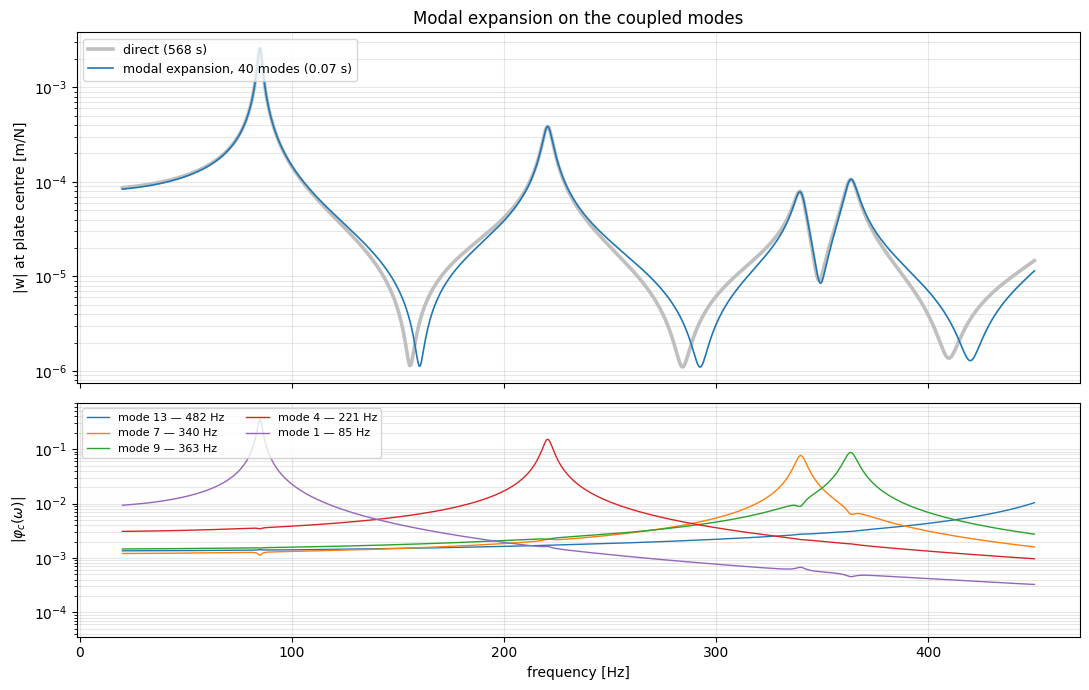

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})

axes[0].semilogy(frequencies, np.abs(w_centre), lw=2.6, color="0.75",
                 label=f"direct ({t_direct:.0f} s)")
axes[0].semilogy(frequencies, np.abs(res_modal["w"][dof]), lw=1.2, color="C0",
                 label=f"modal expansion, {m_c} modes ({t_modal_sweep:.2f} s)")
axes[0].set(ylabel="|w| at plate centre [m/N]",
            title="Modal expansion on the coupled modes")
axes[0].legend(loc="upper left", fontsize=9)

phi = np.abs(res_modal["participations"])
for c in np.argsort(phi.max(axis=1))[-5:]:
    axes[1].semilogy(frequencies, phi[c], lw=1.0,
                     label=f"mode {c} — {coupled_basis['freqs'][c]:.0f} Hz")
axes[1].set(xlabel="frequency [Hz]", ylabel=r"$|\varphi_c(\omega)|$",
            ylim=(phi.max() * 1e-4, phi.max() * 2))
axes[1].legend(loc="upper left", fontsize=8, ncol=2)

for ax in axes:
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 9b. Component Mode Synthesis

CMS never forms the coupled eigenproblem. The two components are solved
separately, both **symmetric**,

$$\mathbf K_s \mathbf \Phi_{su} = \omega_{s}^2\,\mathbf M_s \mathbf \Phi_{su} ,
\qquad
\mathbf K_a \mathbf \Phi_{au} = \omega_{a}^2\,\mathbf M_a \mathbf \Phi_{au} ,$$

the **dry** plate (no pressure load on its face) and the cavity with **rigid
walls**, and their modes are stacked block-diagonally:

$$\begin{Bmatrix}\mathbf w\\ \mathbf p\end{Bmatrix} =
\begin{bmatrix}\mathbf \Phi_{su} & \mathbf 0\\ \mathbf 0 & \mathbf \Phi_{au}\end{bmatrix}
\begin{Bmatrix}\boldsymbol\varphi_s\\ \boldsymbol\varphi_a\end{Bmatrix}.$$

The coupling comes back only in the reduced matrices,

$$\tilde{\mathbf K} = \begin{bmatrix}\mathbf \Lambda_s & -\mathbf A\\
\mathbf 0 & \mathbf \Lambda_a\end{bmatrix},\qquad
\tilde{\mathbf M} = \begin{bmatrix}\mathbf I_s & \mathbf 0\\
\rho_0 \mathbf A^T & \mathbf I_a\end{bmatrix},\qquad
\mathbf A = \mathbf \Phi_{su}^T \mathbf K_c \mathbf \Phi_{au} ,$$

which are still coupled and still unsymmetric: normalizing each component
diagonalizes its own block, nothing more.

In [16]:
t0 = time.time()
cms_basis = build_cms_basis(blocks=blocks_undamped,
                            num_structural=15, num_acoustic=40)
t_basis_cms = time.time() - t0

m_s, m_a = cms_basis["num_structural"], cms_basis["num_acoustic"]
print(f"{m_s + m_a} vectors ({m_s} dry plate + {m_a} rigid cavity), "
      f"built in {t_basis_cms:.2f} s")
print(f"  dry plate    : {np.round(cms_basis['omegas_s'][:5] / (2 * np.pi), 1)} Hz"
      "   (= the in-vacuo frequencies of section 3)")
print(f"  rigid cavity : {np.round(cms_basis['omegas_a'][:5] / (2 * np.pi), 1)} Hz"
      "   (0 Hz = uniform pressure of the sealed cavity)")

# Check the reduced matrices against the block form written above.
Kt_cms, _, Mt_cms = project_coupled_system(cms_basis)
A = cms_basis["modal_coupling"]
Kt_theory = np.block([[np.diag(cms_basis["omegas_s"] ** 2), -A],
                      [np.zeros((m_a, m_s)), np.diag(cms_basis["omegas_a"] ** 2)]])
Mt_theory = np.block([[np.eye(m_s), np.zeros((m_s, m_a))],
                      [RHO0 * A.T, np.eye(m_a)]])
print(f"max |Kt - [[Ls, -A], [0, La]]| / max|Kt| : "
      f"{np.abs(Kt_cms - Kt_theory).max() / np.abs(Kt_theory).max():.1e}")
print(f"max |Mt - [[I, 0], [rho0 A^T, I]]|       : "
      f"{np.abs(Mt_cms - Mt_theory).max():.1e}")

55 vectors (15 dry plate + 40 rigid cavity), built in 0.39 s
  dry plate    : [ 79.  132.8 187.6 222.8 236.6] Hz   (= the in-vacuo frequencies of section 3)
  rigid cavity : [  0.  344.  429.1 549.9 572.4] Hz   (0 Hz = uniform pressure of the sealed cavity)
max |Kt - [[Ls, -A], [0, La]]| / max|Kt| : 8.4e-14
max |Mt - [[I, 0], [rho0 A^T, I]]|       : 4.0e-13


$A_{ij}$ measures how much dry plate mode $i$ and rigid cavity mode $j$ drive each
other: how well that plate shape moves the air the way that cavity mode wants to
move, and how much work that pressure field does on that plate shape. Its pattern
is a set of selection rules — most pairs simply do not talk.

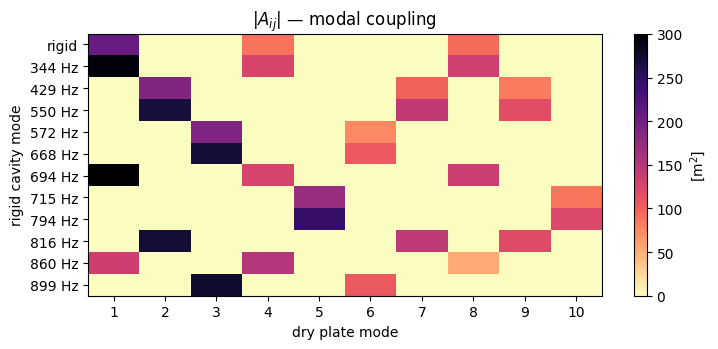

coupling to the uniform-pressure mode, plate modes 1-6:
[207.6704   0.      -0.     -87.5569   0.      -0.    ]


In [17]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
im = ax.imshow(np.abs(A[:10, :12]).T, cmap="magma_r", aspect="auto")
ax.set(xlabel="dry plate mode", ylabel="rigid cavity mode",
       title="$|A_{ij}|$ — modal coupling")
ax.set_xticks(range(10), [str(i + 1) for i in range(10)])
ax.set_yticks(range(12), ["rigid"] + [f"{f:.0f} Hz" for f in
                                      cms_basis["omegas_a"][1:12] / (2 * np.pi)])
fig.colorbar(im, ax=ax, label="[m$^2$]")
plt.tight_layout()
plt.show()

# The uniform-pressure mode is the air spring: it couples to the plate modes that
# change the volume of the cavity, and to no other.
print("coupling to the uniform-pressure mode, plate modes 1-6:")
print(np.round(A[:6, 0], 4))

In [18]:
t0 = time.time()
res_cms = solve_coupled_modal_frequency_sweep(
    cms_basis, frequencies, F_s=F_s, eta_s=ETA_S,
)
t_cms_sweep = time.time() - t0

err_w_cms = np.linalg.norm(res_cms["w"] - result["w"]) / np.linalg.norm(result["w"])
err_p_cms = np.linalg.norm(res_cms["p"] - result["p"]) / np.linalg.norm(result["p"])
print(f"CMS : {frequencies.size} solves of {m_s + m_a:4d} unknowns   "
      f"{t_cms_sweep:6.2f} s   ({t_direct / t_cms_sweep:.0f}x)")
print(f"      error   w {err_w_cms:.1e}   p {err_p_cms:.1e}   "
      f"(modal expansion, {m_c} vectors: w {err_w:.1e})")

CMS : 861 solves of   55 unknowns     0.11 s   (5086x)
      error   w 3.0e-01   p 2.7e-01   (modal expansion, 40 vectors: w 1.7e-02)


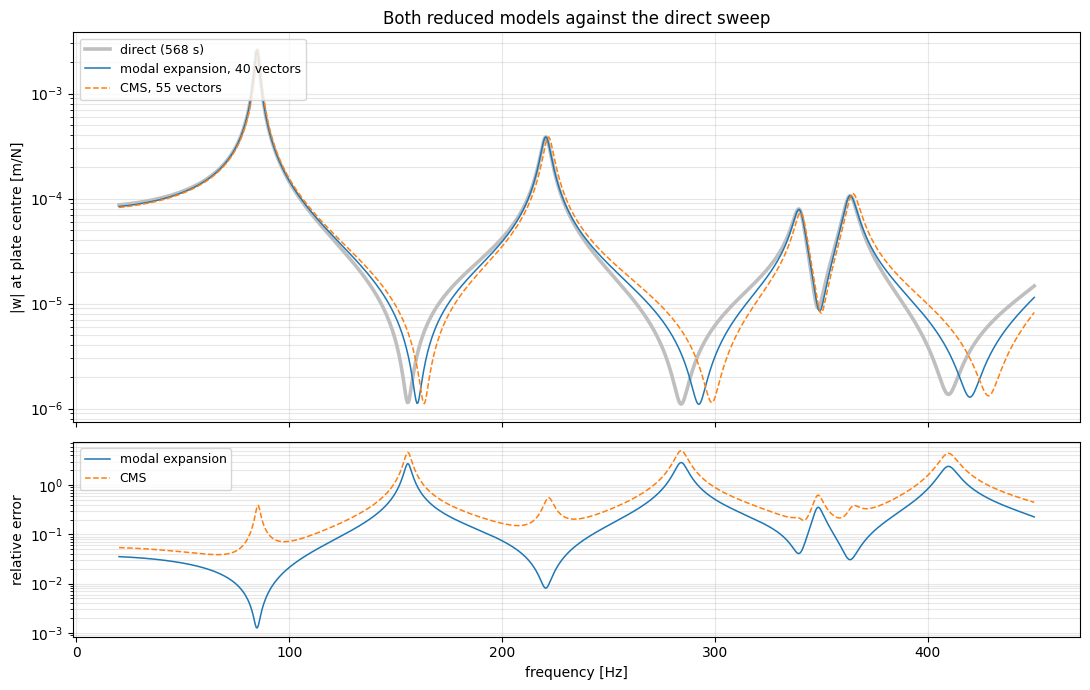

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].semilogy(frequencies, np.abs(w_centre), lw=2.6, color="0.75",
                 label=f"direct ({t_direct:.0f} s)")
axes[0].semilogy(frequencies, np.abs(res_modal["w"][dof]), "-", lw=1.1,
                 color="C0", label=f"modal expansion, {m_c} vectors")
axes[0].semilogy(frequencies, np.abs(res_cms["w"][dof]), "--", lw=1.1,
                 color="C1", label=f"CMS, {m_s + m_a} vectors")
axes[0].set(ylabel="|w| at plate centre [m/N]",
            title="Both reduced models against the direct sweep")
axes[0].legend(loc="upper left", fontsize=9)

for res, style, color, name in ((res_modal, "-", "C0", "modal expansion"),
                                (res_cms, "--", "C1", "CMS")):
    axes[1].semilogy(frequencies,
                     np.abs(res["w"][dof] - w_centre) / np.abs(w_centre),
                     style, lw=1.1, color=color, label=name)
axes[1].set(xlabel="frequency [Hz]", ylabel="relative error")
axes[1].legend(loc="upper left", fontsize=9)

for ax in axes:
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 9c. How the two converge

The comparison to make is at **equal number of vectors**, since that is what sets
the cost of the reduced solve.

In [20]:
def reduced_error(basis):
    """Relative error of a reduced model against the direct sweep."""
    t0 = time.time()
    r = solve_coupled_modal_frequency_sweep(
        basis, frequencies, F_s=F_s, eta_s=ETA_S,
    )
    t = time.time() - t0
    return (np.linalg.norm(r["w"] - result["w"]) / np.linalg.norm(result["w"]),
            np.linalg.norm(r["p"] - result["p"]) / np.linalg.norm(result["p"]),
            np.median(np.abs(r["w"][dof] - w_centre) / np.abs(w_centre)), t)


history = {"modal expansion": [], "CMS": []}
print(" basis              vectors   err w    err p   err at drive   basis    sweep")
for m in (10, 20, 40, 80):
    t0 = time.time()
    b = build_coupled_modal_basis(blocks=blocks_undamped, num_modes=m)
    tb = time.time() - t0
    ew, ep, ed, ts = reduced_error(b)
    history["modal expansion"].append((m, ew))
    print(f" modal expansion    {m:5d}   {ew:.1e}  {ep:.1e}     {ed:.1e}    "
          f"{tb:5.2f} s  {ts:5.2f} s")

for ms, ma in ((5, 15), (10, 30), (20, 60), (40, 160)):
    t0 = time.time()
    b = build_cms_basis(blocks=blocks_undamped,
                        num_structural=ms, num_acoustic=ma)
    tb = time.time() - t0
    ew, ep, ed, ts = reduced_error(b)
    history["CMS"].append((ms + ma, ew))
    print(f" CMS {ms:3d}s + {ma:3d}a    {ms + ma:5d}   {ew:.1e}  {ep:.1e}     "
          f"{ed:.1e}    {tb:5.2f} s  {ts:5.2f} s")

 basis              vectors   err w    err p   err at drive   basis    sweep


/Users/danielefabbri/Desktop/pycafe_new/pycafe/solver/solver_vibroacoustic_modal.py:584: RuntimeWarning: The basis reaches 363.4 Hz, below the usual 2 x f_max = 900.0 Hz rule; the response near the top of the sweep is likely truncated.
  warnings.warn(


 modal expansion       10   6.4e-02  1.8e-02     4.1e-01     0.36 s   0.05 s


/Users/danielefabbri/Desktop/pycafe_new/pycafe/solver/solver_vibroacoustic_modal.py:584: RuntimeWarning: The basis reaches 599.8 Hz, below the usual 2 x f_max = 900.0 Hz rule; the response near the top of the sweep is likely truncated.
  warnings.warn(


 modal expansion       20   2.6e-02  9.1e-03     2.2e-01     0.43 s   0.05 s


...

 modal expansion       80   1.2e-02  6.6e-03     9.4e-02     0.82 s   0.16 s


 CMS   5s +  15a       20   5.2e-01  7.6e-01     7.9e-01     0.31 s   0.06 s


 CMS  10s +  30a       40   3.4e-01  3.2e-01     5.1e-01     0.40 s   0.07 s


 CMS  20s +  60a       80   2.3e-01  2.2e-01     2.8e-01     0.62 s   0.15 s


 CMS  40s + 160a      200   1.4e-01  1.3e-01     1.5e-01     1.76 s   2.65 s


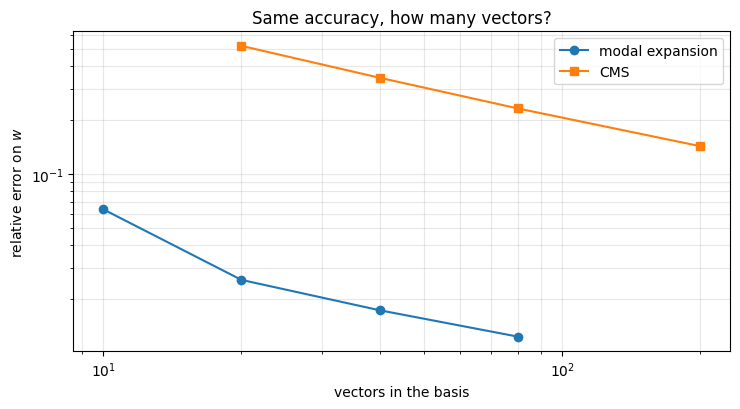

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, marker in (("modal expansion", "o"), ("CMS", "s")):
    sizes, errs = zip(*history[name])
    ax.loglog(sizes, errs, marker + "-", label=name)
ax.set(xlabel="vectors in the basis", ylabel="relative error on $w$",
       title="Same accuracy, how many vectors?")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

The ranking is the one the theory predicts, and the reason is physical. A CMS
acoustic mode is computed with a **rigid** interface, $u_{f,n} = 0$, while the true
condition there is $u_{f,n} = u_{s,n}$: the field a vibrating plate produces near
its own surface is largely evanescent, with strong normal gradients, and global
rigid-wall modes rebuild it slowly. So CMS buys a cheap basis and pays for it in
size — while the coupled modes, which already know about the interface, are worth
far more per vector but need the unsymmetric eigenproblem solved first.

Two refinements exist for the CMS side, neither implemented here: acoustic modes
computed with an **impedance** condition on the interface instead of a rigid wall —
efficient, but choosing $Z$ is an open question, since $Z \to \infty$ falls back to
the rigid wall and $Z \to 0$ to a pressure-release surface — and **fixed-interface
modes** ($p = 0$ on the interface) plus one **constraint mode** per interface DOF,
exact in principle but adding up to $N_\Gamma$ vectors, which leaves little
reduction on a finely meshed interface.

Note what neither basis fixes: the error is largest **at the driven point**, and at
the anti-resonances, where the response is a cancellation between modes. The
vectors left out still carry a quasi-static flexibility that a point load — broad
in space — excites strongly. Judge convergence on a global norm or away from the
drive, and keep the direct solver as the reference.

### 9d. The three routes side by side

Everything measured so far, in one place. The three ways of answering the same
forced problem are:

* **direct** — assemble and factorize $\mathbf A(\omega)$ at every frequency, no
  basis, no approximation. This is the reference the errors are measured against;
* **coupled modal basis** — the modes of the coupled system (§9a): expensive to
  build, since it needs the unsymmetric eigenproblem, then very few vectors;
* **two-domain modal basis (CMS)** — dry plate modes and rigid cavity modes,
  each from its own symmetric eigenproblem (§9b): cheap to build, needs more
  vectors.

The basis cost is listed apart from the sweep cost because it is paid once: over a
long sweep, or over several load cases on the same model, only the second column
keeps growing.

In [22]:
rows = [
    # name, unknowns per solve, basis time, sweep time, err w, err p
    ("direct", blocks["n_s"] + blocks["n_a"], 0.0, t_direct, 0.0, 0.0),
    ("coupled modal basis", m_c, t_basis_coupled, t_modal_sweep, err_w, err_p),
    ("two-domain basis (CMS)", m_s + m_a, t_basis_cms, t_cms_sweep,
     err_w_cms, err_p_cms),
]

head = (f"{'method':<24}{'unknowns':>9}{'basis [s]':>11}{'sweep [s]':>11}"
        f"{'total [s]':>11}{'speed-up':>10}{'err w':>10}{'err p':>10}")
print(head)
print("-" * len(head))
for name, n, t_b, t_s, e_w, e_p in rows:
    total = t_b + t_s
    speed = "—" if name == "direct" else f"{t_direct / t_s:.0f}x"
    err_w_s = "—" if name == "direct" else f"{e_w:.1e}"
    err_p_s = "—" if name == "direct" else f"{e_p:.1e}"
    print(f"{name:<24}{n:>9}{t_b:>11.2f}{t_s:>11.2f}{total:>11.2f}"
          f"{speed:>10}{err_w_s:>10}{err_p_s:>10}")

print(f"\n{frequencies.size} frequencies, {frequencies[0]:.0f}-{frequencies[-1]:.0f} Hz."
      "  Errors are relative 2-norms over the whole sweep, against the direct solution;"
      "\nthe speed-up counts the sweep alone, so the basis column is what a short sweep"
      " has to earn back.")

method                   unknowns  basis [s]  sweep [s]  total [s]  speed-up     err w     err p
------------------------------------------------------------------------------------------------
direct                       8521       0.00     567.65     567.65         —         —         —
coupled modal basis            40       0.53       0.07       0.60     7611x   1.7e-02   8.4e-03
two-domain basis (CMS)         55       0.39       0.11       0.50     5086x   3.0e-01   2.7e-01

861 frequencies, 20-450 Hz.  Errors are relative 2-norms over the whole sweep, against the direct solution;
the speed-up counts the sweep alone, so the basis column is what a short sweep has to earn back.


## What to take away

* **One matrix does the coupling.** $\mathbf K_c$ is built once, on the shared faces
  of a conforming mesh, and reused by both solvers. Its column sum is the vector
  area of the interface — check it before trusting anything downstream.
* **The modes explain the response.** Every peak of the direct sweep sits on a
  coupled natural frequency to well under a hertz, and the energy split says whether
  the peak is the plate, the air, or both.
* **Sealed air is a spring.** The first CCCC plate mode moves up by several percent;
  higher modes, which slosh the air rather than compress it, move down instead.
* **The direct sweep is the expensive part.** The complex unsymmetric matrix has to
  be factorized once per frequency, while the whole modal analysis costs a fraction
  of a second — the reason modal methods exist, and the reason a fine sweep is
  usually run only where the modes say something happens.
* **Reduction is optional, and it is a trade.** Both bases turn a 28 s sweep into a
  fraction of a second, the coupled modes at a few 1e-3 of error with 40 vectors,
  CMS needing several times more for the same — cheap basis, less efficient basis.
* **Watch the resolution.** With $\eta_s = 0.02$ a peak at 100 Hz is about 2 Hz wide:
  a coarser step than that does not shift the peak, it just misses its height.

### Limits of this model

* The cavity is sealed and the walls are almost rigid — no radiation to the outside,
  so nothing here is a transmission-loss calculation.
* Damping is a loss factor plus a lined wall, not a measured material model.
* The mesh is accurate to ~1% up to roughly $c_0/(13h) \approx 650$ Hz for the fluid;
  the plate discretization is the tighter limit at high frequency, where the modal
  density of the plate grows first.

**See also** — `cquad4_plate_validation.ipynb` (the shell element against Nastran and
Leissa), `hexa8_cavity_validation.ipynb` (the acoustic element against the exact
cavity modes), `acoustic_response_2d_3d.ipynb` (all acoustic boundary conditions,
direct *and* modal superposition on the uncoupled fluid).